# ALTH2013HSCC: reachable sets of nonlinear systems by conservative polynomialization

Althoff, M. (2013). Reachability analysis of nonlinear systems using conservative polynomialization and non-convex sets. *HSCC 2013*, pp. 173-182.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ASAG-ISCAS/PyBDR/blob/master/examples/alth2013hscc.ipynb)

Each case is independent. Some cases run for several minutes; the outputs stored in this notebook show the results without running it.

In [1]:
# install PyBDR when running on Colab (skipped when it is already installed)
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pybdr") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pybdr @ git+https://github.com/ASAG-ISCAS/PyBDR"])

In [2]:
%matplotlib inline

import numpy as np
from pybdr.algorithm import ALTH2013HSCC
from pybdr.dynamic_system import NonLinSys
from pybdr.geometry import Geometry, Zonotope, Interval
from pybdr.geometry.operation import cvt2, boundary
from pybdr.model import *
from pybdr.util.visualization import plot, plot_cmp
from pybdr.util.functional import performance_counter_start, performance_counter

## Case 0

model `vanderpol`, `t_end = 6.74`, `step = 0.005`

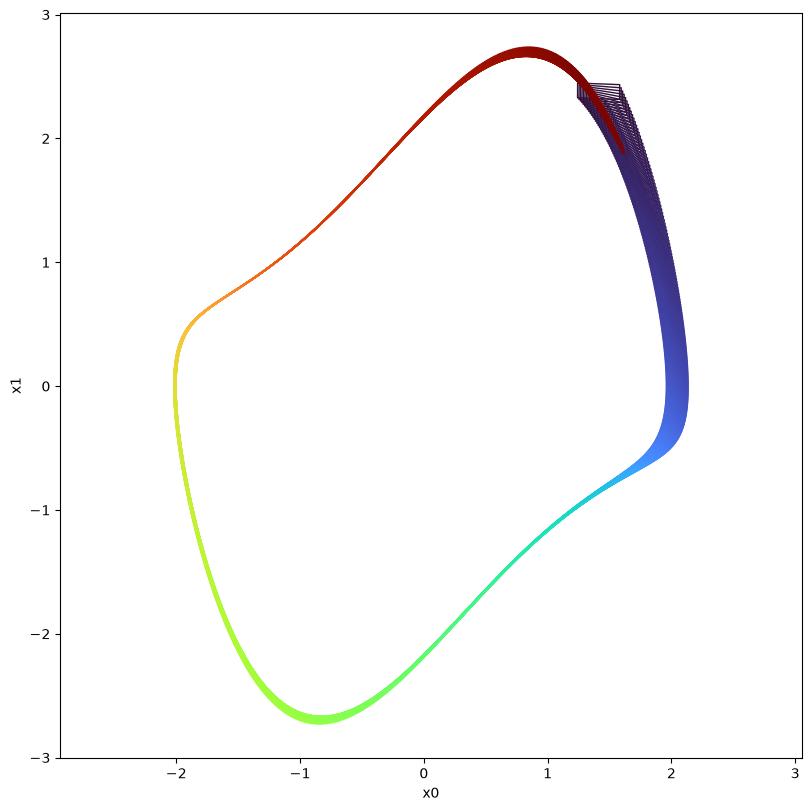

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [3]:
options = ALTH2013HSCC.Options()
options.t_end = 6.74
options.step = 0.005
options.taylor_terms = 4
options.tensor_order = 3
# options.r0 = [Zonotope([1.4, 2.4], np.diag([0.17, 0.06]))]
options.u = Zonotope.zero(1, 1)
options.u_trans = np.zeros(1)
x0 = Zonotope([1.4, 2.4], np.diag([0.17, 0.06]))

# settings for using Zonotope
Zonotope.ORDER = 50
Zonotope.INTERMEDIATE_ORDER = 50
Zonotope.ERROR_ORDER = 20

# reachable sets
ri, rp = ALTH2013HSCC.reach(vanderpol, [2, 1], options, x0)

# visualize the results
plot(rp, [0, 1])

## Case 1

model `vanderpol`, `t_end = 6.74`, `step = 0.005`, boundary analysis (`reach_parallel`)

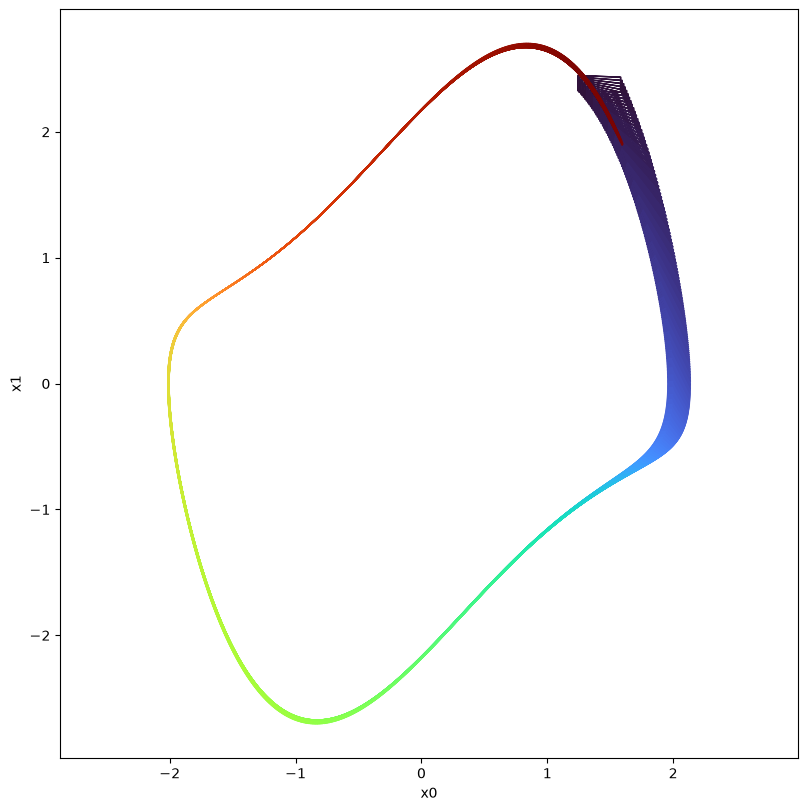

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [4]:
options = ALTH2013HSCC.Options()
options.t_end = 6.74
options.step = 0.005
options.taylor_terms = 4
options.tensor_order = 3
options.u = Zonotope.zero(1, 1)
options.u_trans = np.zeros(1)

x0 = Interval([1.23, 2.34], [1.57, 2.46])
xs = boundary(x0, 1, Geometry.TYPE.ZONOTOPE)

# settings for using Zonotope
Zonotope.ORDER = 50
Zonotope.INTERMEDIATE_ORDER = 50
Zonotope.ERROR_ORDER = 20

# reachable sets
ri, rp = ALTH2013HSCC.reach_parallel(vanderpol, [2, 1], options, xs)

# visualize the results
plot(rp, [0, 1])

## Pi controller with disturbance cmp

model `pi_controller_with_disturbance`, `t_end = 4`, `step = 0.01`, boundary analysis (`reach_parallel`)

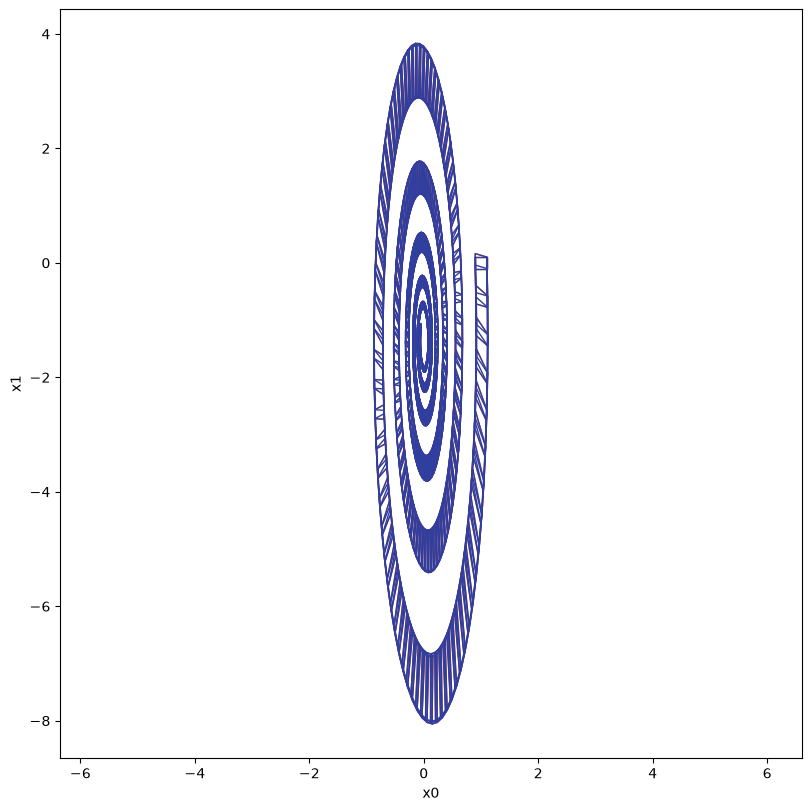

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [5]:
options = ALTH2013HSCC.Options()
options.t_end = 4
options.step = 0.01
options.tensor_order = 3
options.taylor_terms = 4

options.u = Zonotope([0], np.diag([0]))
options.u_trans = options.u.c

# settings for the using geometry
Zonotope.REDUCE_METHOD = Zonotope.REDUCE_METHOD.GIRARD
Zonotope.ORDER = 50

z = Interval([0.9, -0.1], [1.1, 0.1])
x0 = cvt2(z, Geometry.TYPE.ZONOTOPE)
xs = boundary(z, 1, Geometry.TYPE.ZONOTOPE)

ri_without_bound, rp_without_bound = ALTH2013HSCC.reach(pi_controller_with_disturbance, [2, 1], options, x0)
ri_with_bound, rp_with_bound = ALTH2013HSCC.reach_parallel(pi_controller_with_disturbance, [2, 1], options, xs)

# visualize the results
plot_cmp([ri_without_bound, ri_with_bound], [0, 1], cs=["#FF5722", "#303F9F"])

## Vanderpol cmp

model `vanderpol`, `t_end = 6.74`, `step = 0.005`, boundary analysis (`reach_parallel`)

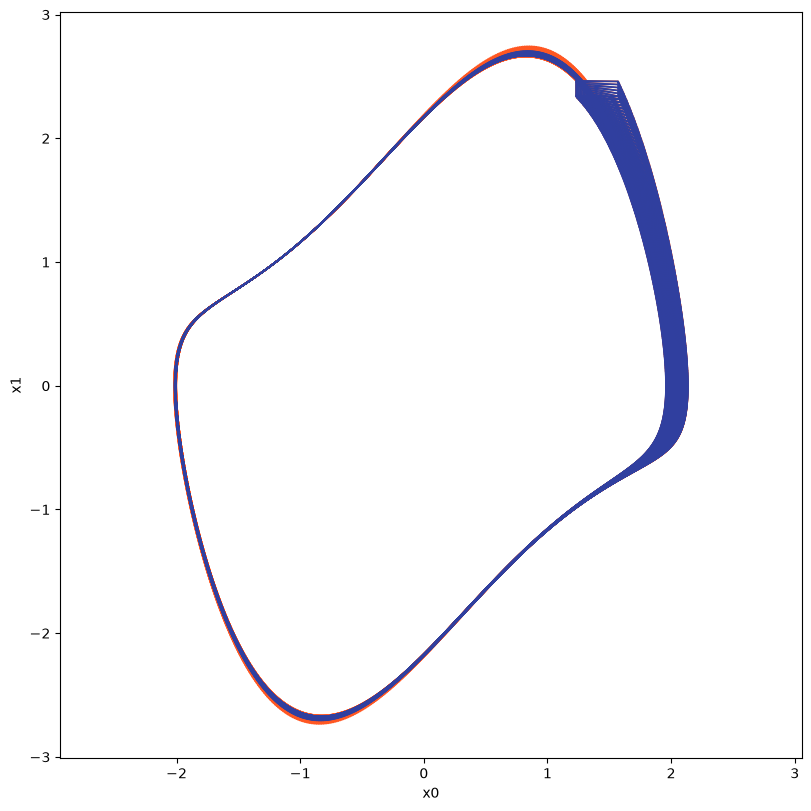

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [6]:
options = ALTH2013HSCC.Options()
options.t_end = 6.74
options.step = 0.005
options.taylor_terms = 4
options.tensor_order = 3
options.u = Zonotope.zero(1, 1)
options.u_trans = np.zeros(1)

# settings for using Zonotope
Zonotope.ORDER = 50
Zonotope.INTERMEDIATE_ORDER = 50
Zonotope.ERROR_ORDER = 20

z = Interval([1.23, 2.34], [1.57, 2.46])

x0 = cvt2(z, Geometry.TYPE.ZONOTOPE)
xs = boundary(z, 1, Geometry.TYPE.ZONOTOPE)

ri_without_bound, rp_without_bound = ALTH2013HSCC.reach(vanderpol, [2, 1], options, x0)
ri_with_bound, rp_with_bound = ALTH2013HSCC.reach_parallel(vanderpol, [2, 1], options, xs)

# visualize the results
plot_cmp([ri_without_bound, ri_with_bound], [0, 1], cs=["#FF5722", "#303F9F"])

## Tank6eq

model `tank6eq`, `t_end = 400`, `step = 4`, boundary analysis (`reach_parallel`)

reach cost: 32.694317375000004s


reach_parallel cost: 101.91392208300002s


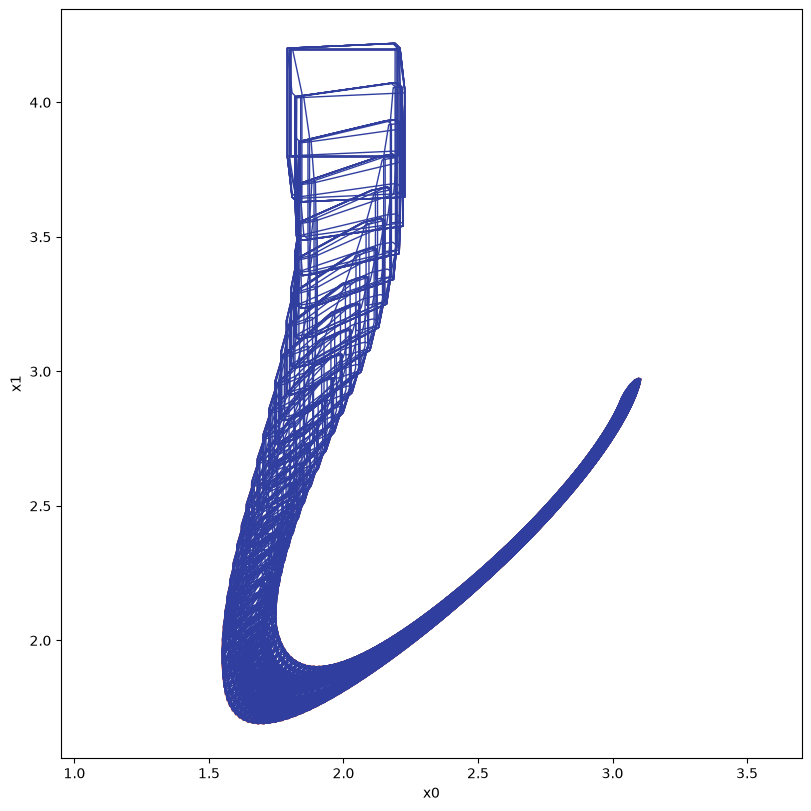

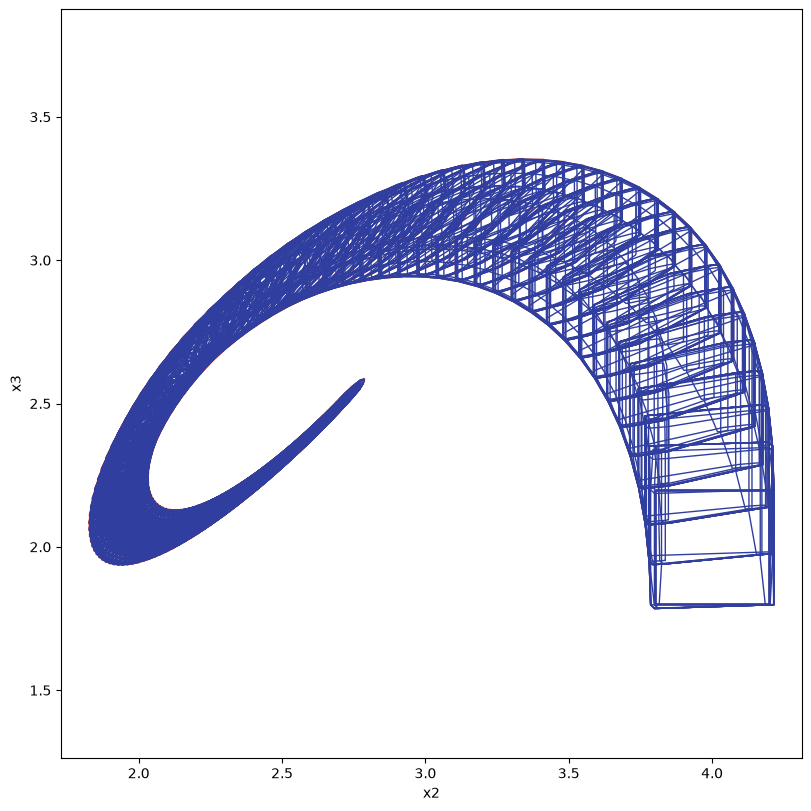

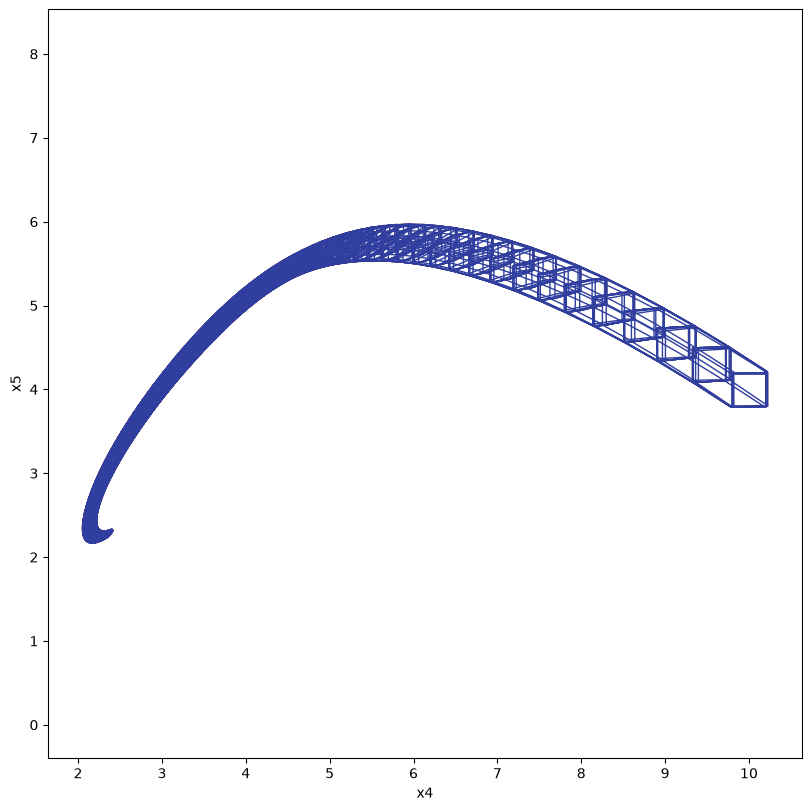

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x4', ylabel='x5'>)

In [7]:
options = ALTH2013HSCC.Options()
options.t_end = 400
options.step = 4
options.taylor_terms = 4
options.tensor_order = 3
options.u = Zonotope.zero(1, 1)
options.u_trans = np.zeros(1)

# settings for using Zonotope
Zonotope.ORDER = 50
Zonotope.INTERMEDIATE_ORDER = 50
Zonotope.ERROR_ORDER = 20

c = np.array([2, 4, 4, 2, 10, 4])
z = Interval(c - 0.2, c + 0.2)

x0 = cvt2(z, Geometry.TYPE.ZONOTOPE)
xs = boundary(z, 1, Geometry.TYPE.ZONOTOPE)

time_tag = performance_counter_start()

ri_without_bound, rp_without_bound = ALTH2013HSCC.reach(tank6eq, [6, 1], options, x0)
time_tag = performance_counter(time_tag, 'reach')

ri_with_bound, rp_with_bound = ALTH2013HSCC.reach_parallel(tank6eq, [6, 1], options, xs)
time_tag = performance_counter(time_tag, 'reach_parallel')

# visualize the results
plot_cmp([ri_without_bound, ri_with_bound], [0, 1], cs=["#FF5722", "#303F9F"])
plot_cmp([ri_without_bound, ri_with_bound], [2, 3], cs=["#FF5722", "#303F9F"])
plot_cmp([ri_without_bound, ri_with_bound], [4, 5], cs=["#FF5722", "#303F9F"])